In [1]:
%cd ..

/home/xl/agentECG


In [2]:
import matplotlib.pyplot as plt
import wfdb
from data.EcgSignals import EcgSignals

In [3]:
paths = ["dataset/dataset_1/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/records100/00000/00413_lr"]

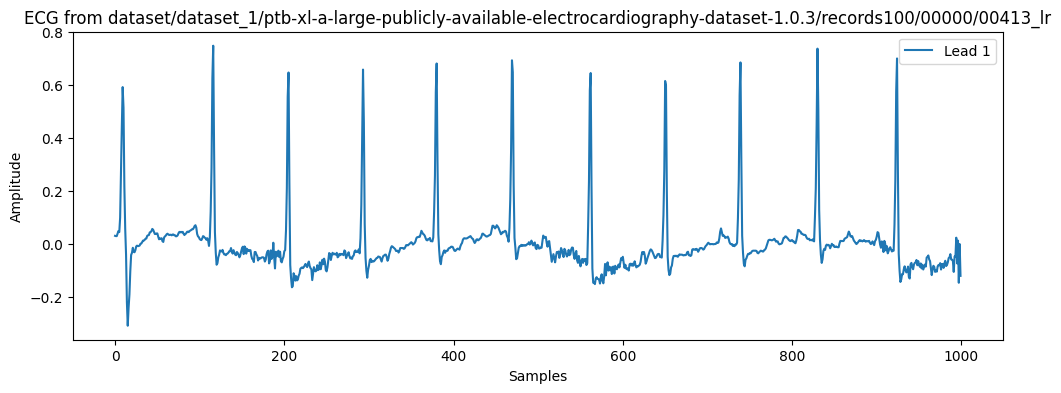

In [4]:
# 遍历 paths 列表，读取并绘制每个心电图
for path in paths:
    try:
        # 读取心电图数据
        record = wfdb.rdrecord(path)
        
        # 获取心电图信号
        signal = record.p_signal[:1000,:1]
        
        # 绘制心电图
        plt.figure(figsize=(12, 4))
        for i in range(signal.shape[1]):  # 遍历所有导联
            plt.plot(signal[:, i], label=f'Lead {i+1}')
        plt.title(f'ECG from {path}')
        plt.xlabel('Samples')
        plt.ylabel('Amplitude')
        plt.legend()
        plt.savefig(f'ecg_plot_{path.split("/")[-1]}.png')  # 保存图像
        plt.show()
    except FileNotFoundError:
        print(f"File not found: {path}")
    except Exception as e:
        print(f"An error occurred while processing {path}: {e}")

In [9]:
signals,fileds = wfdb.rdsamp(path)
sig_name = fileds['sig_name']
sig_name

['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

In [5]:
# 

In [14]:
# 新单元：保存仅包含线条的矢量图（不修改已有单元）
# 函数：save_lines_only_vector
# - 将绘图的坐标轴、刻度和边框全部去掉
# - 支持保存为 SVG/PDF/EPS 等矢量格式
# - 使用时传入 x, y 序列（y 可以为 1D 或 2D：多条曲线）

import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from typing import Union, Iterable
import os
import shutil


def save_lines_only_vector(
    x: 'Union[Iterable, np.ndarray]',
    y: 'Union[Iterable, np.ndarray]',
    filename: str = 'lines_only.svg',
    vector_format: str = 'svg',
    linewidth: float = 1.0,
    colors=None,
    background: str = 'transparent',
    lead_name: str = None,
    lead_label_fontsize: int = 24,
    lead_label_color: str = 'black'
):
    """
    Save a vector graphic containing only the plotted lines (no axes, ticks, or spines).
    Args:
        x: 1D x values.
        y: 1D y values or 2D array-like for multiple lines.
        filename: output filename (extension optional). Appends if missing.
        vector_format: 'svg', 'pdf', 'eps', etc.
        linewidth: line width.
        colors: single color or list of colors for multiple lines.
        background: background color, '#xxxxxx' or 'transparent' (default).
        lead_name: string; if set, will be drawn at top-left as lead label.
        lead_label_fontsize: font size of lead label.
        lead_label_color: color of lead label.
    """
    x_arr = np.asarray(x)
    y_arr = np.asarray(y)

    # Normalize filename extension
    if not filename.lower().endswith('.' + vector_format.lower()):
        filename = f"{filename}.{vector_format}"

    fig, ax = plt.subplots(figsize=(8, 3))
    # Set the background color
    if background == 'transparent':
        fig.patch.set_alpha(0.0)
        ax.patch.set_alpha(0.0)
    else:
        fig.patch.set_facecolor(background)
        ax.set_facecolor(background)

    # Plot handling for 1D or 2D y
    if y_arr.ndim == 1:
        ax.plot(x_arr, y_arr, linewidth=linewidth, color=(colors if colors is not None else 'black'))
    else:
        # y_arr shape: (n_lines, n_points) or (n_points, n_lines)
        if y_arr.shape[0] == x_arr.size:
            y_plot = y_arr.T
        else:
            y_plot = y_arr
        for idx, yi in enumerate(y_plot):
            col = None
            if colors is not None:
                try:
                    col = colors[idx]
                except Exception:
                    col = colors
            ax.plot(x_arr, yi, linewidth=linewidth, color=(col if col is not None else 'black'))

    # Remove axes, ticks and margins so only the lines remain
    ax.axis('off')

    # Insert lead name in upper left if provided
    if lead_name is not None:
        ax.text(
            0.01, 0.98, lead_name,
            transform=ax.transAxes,
            fontsize=lead_label_fontsize,
            color=lead_label_color,
            fontweight='bold',
            va='top',
            ha='left',
            bbox=dict(facecolor='none', edgecolor='none', pad=0)
        )

    plt.tight_layout(pad=0)
    plt.savefig(
        filename,
        format=vector_format,
        bbox_inches='tight',
        transparent=(background == 'transparent')
    )
    plt.close(fig)



# 示例：单条正弦波
if __name__ == '__main__':
    # 创建文件夹
    dir_name = "example_ecg"
    if os.path.exists(dir_name):
        shutil.rmtree(dir_name)
    os.makedirs(dir_name)


    
    signals,fileds = wfdb.rdsamp(path)
    sig_name = fileds['sig_name']
    for i in range(len(sig_name)):
        t = np.linspace(0, 2 * np.pi, 1000)
        y = signals[:,i]  # pyright: ignore[reportOptionalSubscript]
        save_lines_only_vector(t, y, filename=f'{dir_name}/lines_only_example_{sig_name[i]}.svg', vector_format='svg', background='#ffe3f1', linewidth=1.5,lead_name=sig_name[i])


